In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import re
import sys
import ast
import seaborn as sns
from pathlib import Path
from natsort import natsorted
from sklearn.metrics import roc_curve
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
from statsmodels.stats.proportion import proportion_confint
import pyagrum as gum


sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import load_config, get_cur_dir, create_clean_dir, set_seed

import gc
import multiprocessing  # noqa: F401 # pylint: disable=unused-import
import sys
import pyagrum.lib.notebook as gnb
import pyagrum.skbn as skbn

import numpy as np  # noqa: F401 # pylint: disable=unused-import
import pandas as pd
from joblib import Parallel, delayed

from src.attack import attack_mechanism
from src.config import create_clean_dir, get_cur_dir, load_config, map_sys_args
from src.defense import defense_mechanism
from src.inference import inferences
from src.mia import find_epsilon, mia_vs_cn
from src.learning import estimate_bns


In [6]:
# Init exps configs
config = load_config("cn_vs_noisybn")
cur_dir = get_cur_dir(config)
create_clean_dir(cur_dir / "output")
num_cores = eval(config["num_cores"])

# Set paths
cur_dir = get_cur_dir(config)
bns_path = cur_dir / config["bns_path"]
data_path = cur_dir / config["data_path"]

# Create empty directories
create_clean_dir(bns_path)
create_clean_dir(bns_path / "gt")
create_clean_dir(bns_path / "rpop")
create_clean_dir(bns_path / "pool")
create_clean_dir(data_path)

# Set seed
set_seed()

In [7]:
from ucimlrepo import fetch_ucirepo

# Import gpop
breast_cancer = fetch_ucirepo(id=14)
features = breast_cancer.data.features
target = breast_cancer.data.targets
gpop = pd.concat([features, target], axis=1)

# Preprocessing
gpop = gpop.dropna()
gpop.columns = [str.replace(col, "-", "_") for col in gpop.columns]
gpop[gpop.columns] = gpop[gpop.columns].astype("category")
gpop["Class"] = gpop["Class"].apply(lambda x: 1 if x=="recurrence-events" else 0) 
gpop.rename(columns={"Class":"T"}, inplace = True)
gpop = gpop.apply(lambda x: x.cat.codes)

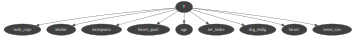

In [8]:
# Learn 'gt' model
classifier = skbn.BNClassifier(learningMethod="NaiveBayes")
classifier.fit(data=gpop, targetName="T")
gt = classifier.bn

gnb.showBN(gt)

gum.saveBN(gt, f'{bns_path / "gt"}/{f"exp0"}.bif')

In [9]:
# Create pool and rpop samples
gpop_ss = len(gpop)
pool_ss = int(gpop_ss * config["pool_prop"])
rpop_ss = int(gpop_ss * config["rpop_prop"])

# For any data sample ...
for sample in range(config["samples"]):

    # ... sample pool and rpop
    shuffled_idx = np.random.permutation(gpop.index)

    pool_idx = shuffled_idx[:pool_ss]
    rpop_idx = shuffled_idx[pool_ss : pool_ss + rpop_ss]

    gpop[f"in-pool-{sample}"] = gpop.index.isin(pool_idx)
    gpop[f"in-rpop-{sample}"] = gpop.index.isin(rpop_idx)

# Save gpop
gpop.to_csv(f"{data_path}/exp0.csv", index=False)

In [10]:
# Estimate BNs from rpop and pool
estimate_bns("exp0", config)